# MobileNetV2 3-Class Image Classification with Keras - Center Crop

This notebook trains a 3-class classifier using `MobileNetV2` transfer learning with a configurable `alpha` width multiplier.

Images are center-cropped to the target aspect ratio before resizing, matching a `320x240 -> center 240x240 -> 160x160` ESP32 preprocessing path.

In [37]:
from pathlib import Path
from typing import List
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.10.0
GPU available: True


In [38]:
SEED = 42
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 16
HEAD_EPOCHS = 10
ALPHA = 0.35
L2_STRENGTH = 0.005
CENTER_CROP_FRACTION = 0.75
CLASS_NAMES = ['Amine', 'Rifki', 'Jakub']
DATA_ROOT = Path('../data')
MODEL_PATH = Path('saved_model/mobilenetv2_3class_classifier.keras')

keras.utils.set_random_seed(SEED)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Could not find dataset directory: {DATA_ROOT.resolve()}')

print('Data root:', DATA_ROOT.resolve())
print('Alpha:', ALPHA)

Data root: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\data
Alpha: 0.35


In [39]:
def center_crop_array(array, crop_fraction=CENTER_CROP_FRACTION):
    if not 0 < crop_fraction <= 1:
        raise ValueError('CENTER_CROP_FRACTION must be in the range (0, 1]')

    height, width = array.shape[:2]
    crop_height = max(1, int(height * crop_fraction))
    crop_width = max(1, int(width * crop_fraction))
    y0 = (height - crop_height) // 2
    x0 = (width - crop_width) // 2
    cropped = array[y0:y0 + crop_height, x0:x0 + crop_width]
    resized = tf.image.resize(cropped, IMAGE_SIZE, method='bilinear')
    return resized.numpy().astype(np.float32)


In [40]:
def collect_split_dataframe(data_root: Path, class_names: List[str], split: str) -> pd.DataFrame:
    records = []
    valid_ext = {'.png', '.jpg', '.jpeg', '.bmp'}

    for class_name in class_names:
        split_dir = data_root / class_name / split
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing split directory: {split_dir}')

        for file_path in sorted(split_dir.iterdir()):
            if file_path.is_file() and file_path.suffix.lower() in valid_ext:
                records.append({'filepath': str(file_path), 'label': class_name})

    if not records:
        raise ValueError(f'No images found for split={split!r}')

    df = pd.DataFrame(records)
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


train_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'train')
test_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'test')

display(train_df.head())
print('Train samples:', len(train_df))
print(train_df['label'].value_counts().sort_index())
print()
print('Test samples:', len(test_df))
print(test_df['label'].value_counts().sort_index())

,filepath,label
0,..\data\Jakub\train\image_20260314_150704.png,Jakub
1,..\data\Amine\train\image_20260321_204014_brig...,Amine
2,..\data\Jakub\train\image_20260314_145634_comp...,Jakub
3,..\data\Rifki\train\image_20260312_074812_occl...,Rifki
4,..\data\Rifki\train\image_20260305_130316_hfli...,Rifki


Train samples: 2160
label
Amine    720
Jakub    720
Rifki    720
Name: count, dtype: int64

Test samples: 540
label
Amine    180
Jakub    180
Rifki    180
Name: count, dtype: int64


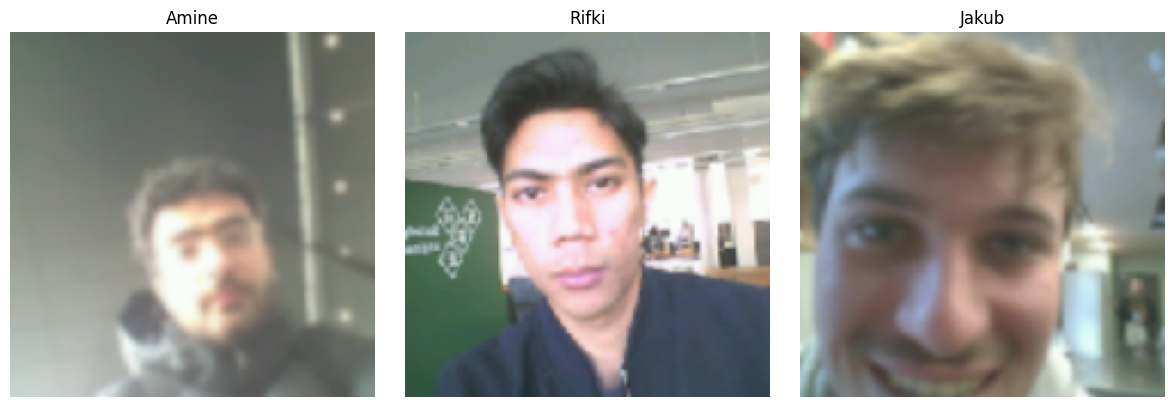

In [41]:
sample_paths = []
for class_name in CLASS_NAMES:
    class_rows = train_df[train_df['label'] == class_name]
    sample_paths.append(class_rows.sample(1, random_state=SEED).iloc[0]['filepath'])

plt.figure(figsize=(12, 4))
for i, image_path in enumerate(sample_paths, start=1):
    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
    image_array = keras.utils.img_to_array(image)
    cropped_image = center_crop_array(image_array).astype(np.uint8)
    plt.subplot(1, len(sample_paths), i)
    plt.imshow(cropped_image)
    plt.title(Path(image_path).parts[-3])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

Run this section before the final training cells to compare a small set of preprocessing and classifier-head settings. It trains short runs, ranks them by validation accuracy and validation loss, and prints the best configuration.

In [42]:
TUNING_EPOCHS = 5

TUNING_CONFIGS = [
    {'crop_fraction': 0.75, 'dropout': 0.3, 'dense_units': 128, 'l2': 0.001, 'learning_rate': 1e-3},
    {'crop_fraction': 0.75, 'dropout': 0.4, 'dense_units': 128, 'l2': 0.001, 'learning_rate': 5e-4},
    {'crop_fraction': 0.70, 'dropout': 0.3, 'dense_units': 128, 'l2': 0.001, 'learning_rate': 1e-3},
    {'crop_fraction': 0.70, 'dropout': 0.4, 'dense_units': 64, 'l2': 0.001, 'learning_rate': 5e-4},
    {'crop_fraction': 0.80, 'dropout': 0.3, 'dense_units': 128, 'l2': 0.0005, 'learning_rate': 1e-3},
]


def make_preprocess_fn(crop_fraction):
    def preprocess_fn(array):
        return preprocess_input(center_crop_array(array, crop_fraction=crop_fraction))
    return preprocess_fn


def make_tuning_generators(crop_fraction):
    tuning_train_datagen = keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=make_preprocess_fn(crop_fraction),
        validation_split=0.2,
        rotation_range=12,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        brightness_range=(0.9, 1.1),
        horizontal_flip=True,
    )

    tuning_train_gen = tuning_train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filepath',
        y_col='label',
        target_size=IMAGE_SIZE,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        subset='training',
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=True,
    )

    tuning_val_gen = tuning_train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filepath',
        y_col='label',
        target_size=IMAGE_SIZE,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        subset='validation',
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=False,
    )

    return tuning_train_gen, tuning_val_gen


def build_tuning_model(config):
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=IMAGE_SIZE + (3,),
        alpha=ALPHA,
    )
    base_model.trainable = False

    inputs = keras.Input(shape=IMAGE_SIZE + (3,))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(config['dropout'])(x)
    x = layers.Dense(
        config['dense_units'],
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(config['l2']),
    )(x)
    x = layers.Dropout(config['dropout'])(x)
    outputs = layers.Dense(
        len(CLASS_NAMES),
        activation='softmax',
        kernel_regularizer=keras.regularizers.l2(config['l2']),
    )(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_3Class_Tuning')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config['learning_rate']),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy'],
    )
    return model


tuning_results = []
for run_id, config in enumerate(TUNING_CONFIGS, start=1):
    print(f'\nTuning run {run_id}/{len(TUNING_CONFIGS)}: {config}')
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    tuning_train_gen, tuning_val_gen = make_tuning_generators(config['crop_fraction'])
    tuning_model = build_tuning_model(config)
    tuning_history = tuning_model.fit(
        tuning_train_gen,
        validation_data=tuning_val_gen,
        epochs=TUNING_EPOCHS,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
        verbose=1,
    )

    best_val_accuracy = max(tuning_history.history['val_accuracy'])
    best_val_loss = min(tuning_history.history['val_loss'])
    tuning_results.append({
        'run_id': run_id,
        **config,
        'best_val_accuracy': best_val_accuracy,
        'best_val_loss': best_val_loss,
        'epochs_run': len(tuning_history.history['loss']),
    })

tuning_df = pd.DataFrame(tuning_results).sort_values(
    ['best_val_accuracy', 'best_val_loss'],
    ascending=[False, True],
).reset_index(drop=True)

display(tuning_df)
best_config = tuning_df.iloc[0].to_dict()
print('Best config:')
print(best_config)


Tuning run 1/5: {'crop_fraction': 0.75, 'dropout': 0.3, 'dense_units': 128, 'l2': 0.001, 'learning_rate': 0.001}
Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Epoch 1/5
108/108 [==============================] - 19s 169ms/step - loss: 0.8642 - accuracy: 0.8142 - val_loss: 0.5887 - val_accuracy: 0.9907
Epoch 2/5
108/108 [==============================] - 15s 143ms/step - loss: 0.6299 - accuracy: 0.9444 - val_loss: 0.5306 - val_accuracy: 0.9907
Epoch 3/5
108/108 [==============================] - 16s 148ms/step - loss: 0.5715 - accuracy: 0.9682 - val_loss: 0.5031 - val_accuracy: 0.9977
Epoch 4/5
108/108 [==============================] - 24s 222ms/step - loss: 0.5560 - accuracy: 0.9624 - val_loss: 0.4882 - val_accuracy: 0.9884
Epoch 5/5
108/108 [==============================] - 35s 322ms/step - loss: 0.5282 - accuracy: 0.9716 - val_loss: 0.4679 - val_accuracy: 0.9907

Tuning run 2/5: {'crop_fraction': 0.75, 'dro

,run_id,crop_fraction,dropout,dense_units,l2,learning_rate,best_val_accuracy,best_val_loss,epochs_run
0,1,0.75,0.3,128,0.0010,0.0010,0.997685,0.467949,5
1,5,0.80,0.3,128,0.0005,0.0010,0.995370,0.422379,5
2,4,0.70,0.4,64,0.0010,0.0005,0.993056,0.467444,5
3,3,0.70,0.3,128,0.0010,0.0010,0.993056,0.478906,5
4,2,0.75,0.4,128,0.0010,0.0005,0.986111,0.535380,5


Best config:
{'run_id': 1.0, 'crop_fraction': 0.75, 'dropout': 0.3, 'dense_units': 128.0, 'l2': 0.001, 'learning_rate': 0.001, 'best_val_accuracy': 0.9976851940155029, 'best_val_loss': 0.4679490923881531, 'epochs_run': 5.0}


In [43]:
DEFAULT_FINAL_CONFIG = {
    'crop_fraction': CENTER_CROP_FRACTION,
    'dropout': 0.3,
    'dense_units': 128,
    'l2': L2_STRENGTH,
    'learning_rate': 1e-3,
}

FINAL_CONFIG = dict(DEFAULT_FINAL_CONFIG)
if 'best_config' in globals():
    FINAL_CONFIG.update({
        'crop_fraction': float(best_config['crop_fraction']),
        'dropout': float(best_config['dropout']),
        'dense_units': int(best_config['dense_units']),
        'l2': float(best_config['l2']),
        'learning_rate': float(best_config['learning_rate']),
    })

print('Final training config:', FINAL_CONFIG)


def preprocess_final_input(array):
    return preprocess_input(center_crop_array(array, crop_fraction=FINAL_CONFIG['crop_fraction']))


train_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_final_input,
    validation_split=0.2,
    rotation_range=12,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
)

test_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_final_input,
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    keep_aspect_ratio=True,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='training',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
)

val_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    keep_aspect_ratio=True,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='validation',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    keep_aspect_ratio=True,
    class_mode='categorical',
    classes=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('Class indices:', train_gen.class_indices)

Final training config: {'crop_fraction': 0.75, 'dropout': 0.3, 'dense_units': 128, 'l2': 0.001, 'learning_rate': 0.001}
Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Class indices: {'Amine': 0, 'Rifki': 1, 'Jakub': 2}


In [44]:
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=IMAGE_SIZE + (3,),
    alpha=ALPHA,
)
base_model.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(FINAL_CONFIG['dropout'])(x)
x = layers.Dense(
    FINAL_CONFIG['dense_units'],
    activation='relu',
    kernel_regularizer=keras.regularizers.l2(FINAL_CONFIG['l2']),
)(x)
x = layers.Dropout(FINAL_CONFIG['dropout'])(x)
outputs = layers.Dense(
    len(CLASS_NAMES),
    activation='softmax',
    kernel_regularizer=keras.regularizers.l2(FINAL_CONFIG['l2']),
)(x)


model = keras.Model(inputs, outputs, name='MobileNetV2_3Class')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINAL_CONFIG['learning_rate']),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'],
)


model.summary()

Model: "MobileNetV2_3Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 mobilenetv2_0.35_160 (Funct  (None, 5, 5, 1280)       410208    
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               163968    
                                                                 
 dropout_3 (Dropout)         (None, 128)        

In [45]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True),
]

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)

Epoch 1/10
108/108 [==============================] - 17s 151ms/step - loss: 0.8473 - accuracy: 0.8275 - val_loss: 0.5940 - val_accuracy: 0.9653 - lr: 0.0010
Epoch 2/10
108/108 [==============================] - 16s 144ms/step - loss: 0.6206 - accuracy: 0.9468 - val_loss: 0.5316 - val_accuracy: 0.9838 - lr: 0.0010
Epoch 3/10
108/108 [==============================] - 16s 152ms/step - loss: 0.5702 - accuracy: 0.9653 - val_loss: 0.5046 - val_accuracy: 0.9907 - lr: 0.0010
Epoch 4/10
108/108 [==============================] - 27s 247ms/step - loss: 0.5500 - accuracy: 0.9693 - val_loss: 0.5051 - val_accuracy: 0.9838 - lr: 0.0010
Epoch 5/10
108/108 [==============================] - 35s 329ms/step - loss: 0.5320 - accuracy: 0.9711 - val_loss: 0.4718 - val_accuracy: 0.9884 - lr: 0.0010
Epoch 6/10
108/108 [==============================] - 20s 182ms/step - loss: 0.5027 - accuracy: 0.9769 - val_loss: 0.4473 - val_accuracy: 0.9977 - lr: 0.0010
Epoch 7/10
108/108 [==============================] 

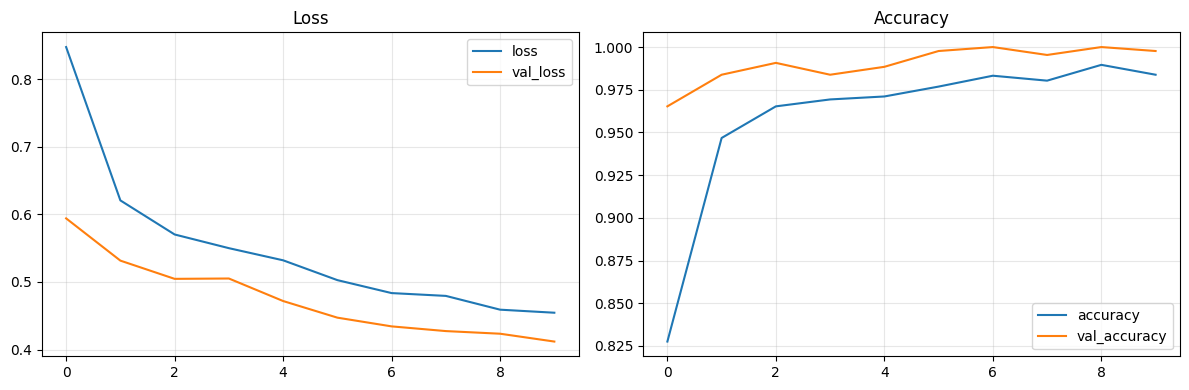

In [46]:
head_history = history_head.history
history = {}
for key in head_history:
    history[key] = head_history.get(key, [])

history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Test loss: 0.5128
Test accuracy: 0.9537

              precision    recall  f1-score   support

       Amine       0.93      0.94      0.94       180
       Rifki       0.97      1.00      0.99       180
       Jakub       0.95      0.92      0.94       180

    accuracy                           0.95       540
   macro avg       0.95      0.95      0.95       540
weighted avg       0.95      0.95      0.95       540



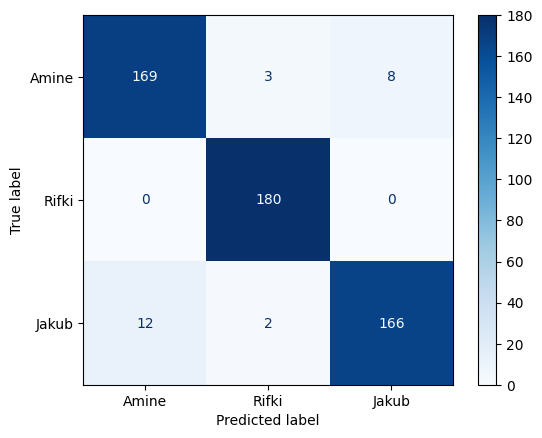

In [47]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

probabilities = model.predict(test_gen, verbose=0)
y_pred = np.argmax(probabilities, axis=1)
y_true = test_gen.classes

print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.show()

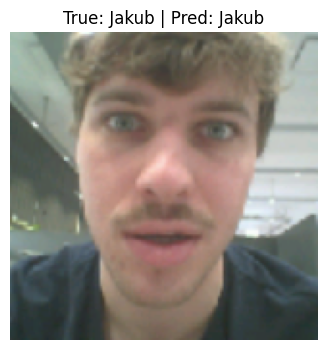

Amine: 0.0222
Rifki: 0.0134
Jakub: 0.9644

Saved model to: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\mobilenetv2_3class_classifier.keras


In [48]:
index_to_class = {v: k for k, v in train_gen.class_indices.items()}
random_row = test_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
sample_path = random_row['filepath']
image = keras.utils.load_img(sample_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
array = keras.utils.img_to_array(image)
cropped_image = center_crop_array(array, crop_fraction=FINAL_CONFIG['crop_fraction']).astype(np.uint8)
array = preprocess_final_input(array)
prediction = model.predict(np.expand_dims(array, axis=0), verbose=0)[0]
predicted_class = index_to_class[int(np.argmax(prediction))]

plt.figure(figsize=(4, 4))
plt.imshow(cropped_image)
plt.title(f'True: {random_row["label"]} | Pred: {predicted_class}')
plt.axis('off')
plt.show()

for class_name, score in zip(CLASS_NAMES, prediction):
    print(f'{class_name}: {score:.4f}')

print('\nSaved model to:', MODEL_PATH.resolve())

## ExportTraining Subset

This section saves the preprocessed training subset used by the MobileNetV2 to `saved_model/x_train.npy` and `saved_model/y_train.npy` for later quantization.

In [49]:
VALIDATION_SPLIT = 0.2
X_TRAIN_PATH = MODEL_PATH.parent / 'x_train.npy'
Y_TRAIN_PATH = MODEL_PATH.parent / 'y_train.npy'


def make_training_subset(train_df: pd.DataFrame) -> pd.DataFrame:
    split_index = int(len(train_df) * VALIDATION_SPLIT)
    return train_df.iloc[split_index:].reset_index(drop=True)


def load_and_preprocess_images(train_subset: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    class_to_index = {name: idx for idx, name in enumerate(CLASS_NAMES)}

    x_train = []
    y_train = []

    for row in train_subset.itertuples(index=False):
        image = keras.utils.load_img(row.filepath, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
        array = keras.utils.img_to_array(image).astype(np.float32)
        array = preprocess_final_input(array)

        x_train.append(array)
        y_train.append(class_to_index[row.label])

    return np.stack(x_train).astype(np.float32), np.array(y_train, dtype=np.int32)


MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
train_subset = make_training_subset(train_df)
x_train, y_train = load_and_preprocess_images(train_subset)

np.save(X_TRAIN_PATH, x_train)
np.save(Y_TRAIN_PATH, y_train)

print(f'Saved training subset: {len(train_subset)} images')
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'Saved: {X_TRAIN_PATH.resolve()}')
print(f'Saved: {Y_TRAIN_PATH.resolve()}')


Saved training subset: 1728 images
x_train shape: (1728, 160, 160, 3)
y_train shape: (1728,)
Saved: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\x_train.npy
Saved: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\y_train.npy
